# **T1**

**Crie um modelo Decision Tree para classificar a qualidade dos vinhos e exiba a árvore gerada.**

**Dados:** https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

Input variables (based on physicochemical tests):

* fixed acidity

* volatile acidity

* citric acid

* residual sugar

* chlorides

* free sulfur dioxide

* total sulfur dioxide

* density

* pH

* sulphates

* alcohol

Output variable (based on sensory data):

* quality (score between 0 and 10)

In [15]:
# Download do conjunto de dados
!gdown 1ttOCd6VQH85CfdRvGXqt4UI3pjF73vJl --quiet

Sugestões de etapas:


1.   Ler os dados
2.   Criação do Label (1 se maior que 5, 0 caso contrário)
3.   Análise do dataset (Valores faltantes, pairplot, matriz de correlação, ...)
4.   Divisão dos dados em treino e teste
5.   Pré-processamento
6.   Treinamento do modelo DecisionTree
7.   Validação do modelo e exibição de uma parte da árvore



# **Referências**

**Árvore de decisão:** https://didatica.tech/como-funciona-o-algoritmo-arvore-de-decisao/

**Aprendizado de máquina: Árvore de Decisão Indutiva:** https://www.cin.ufpe.br/~pacm/SI/ArvoreDecisaoIndutiva.pdf

**DecisionTree scikit-learn:** https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

**Comparação diferentes normalizadores:** https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py

###Resolução T1###

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import classification_report, confusion_matrix
import graphviz
from IPython.display import Image
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

###Ler os dados###


In [17]:
df = pd.read_csv("winequality-red.csv", sep=';')

###Criação do Label (1 se maior que 5, 0 caso contrário)###


In [18]:
df['decisao'] = (df['quality'] > 5).astype(int)

###Análise do dataset (Valores faltantes, pairplot, matriz de correlação, ...)###

In [19]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,decisao
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  decisao               1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


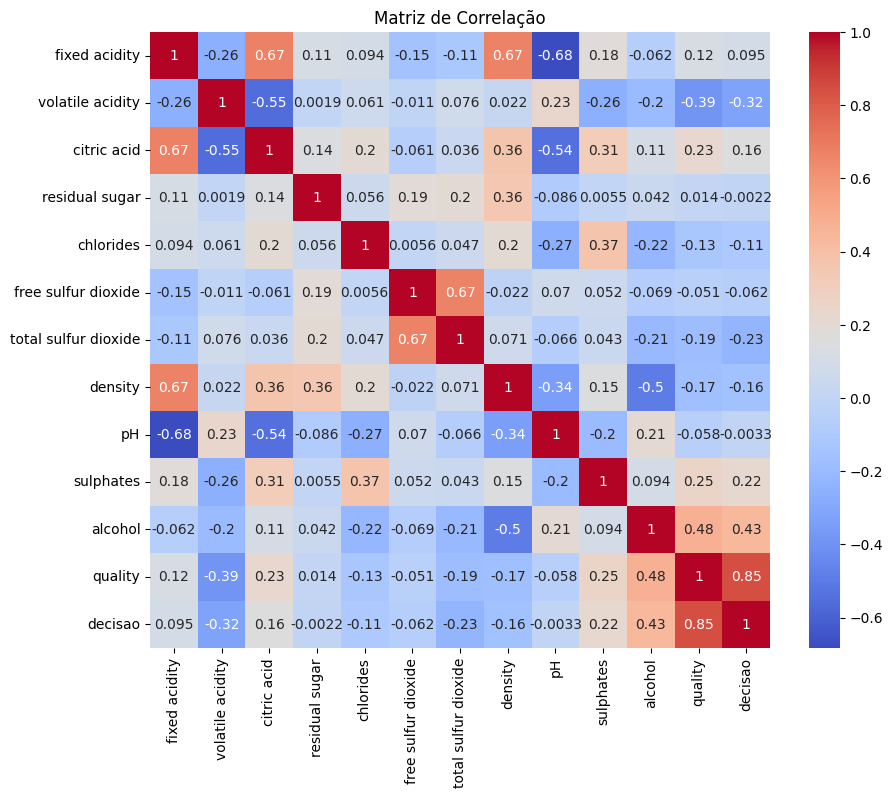

In [21]:
# Matriz de correlação
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

In [22]:
sns.pairplot(df)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

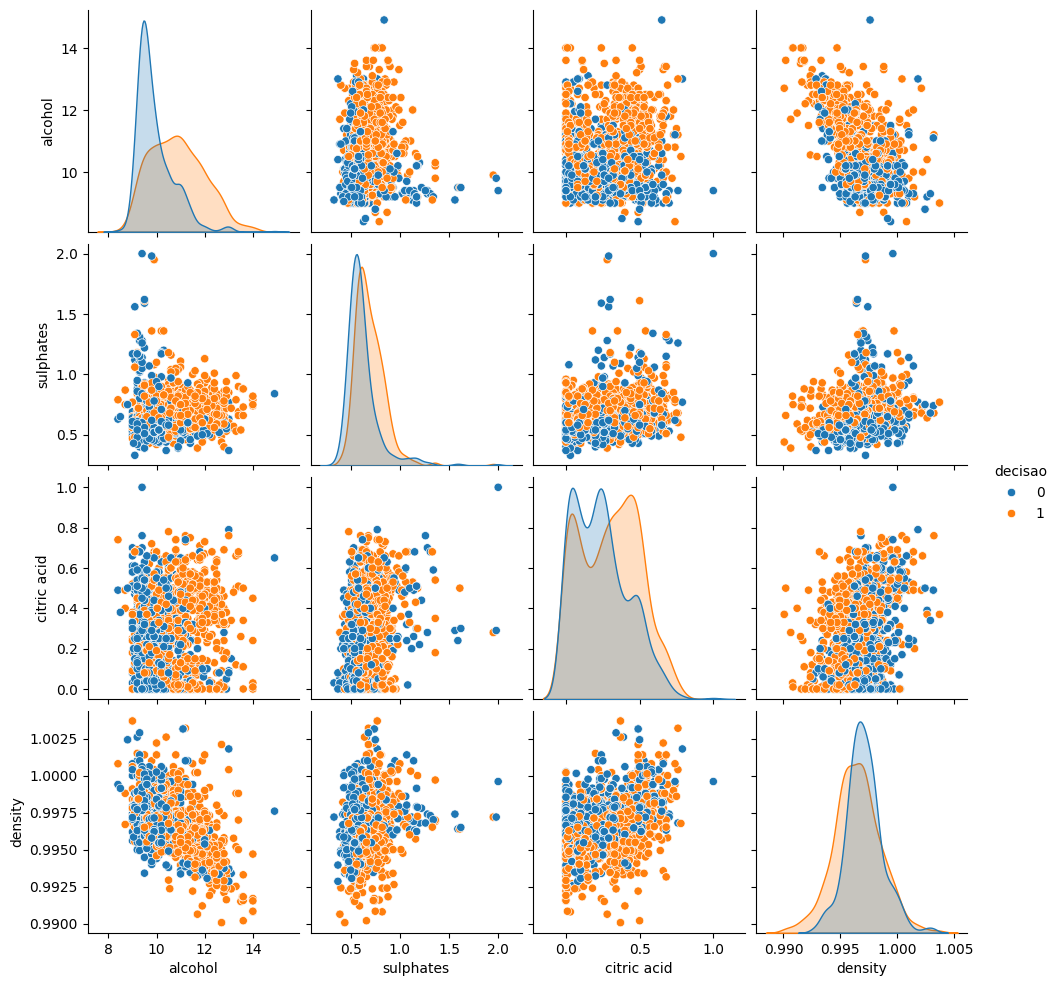

In [23]:
# Pairplot com um subset de variáveis
sns.pairplot(df[['alcohol', 'sulphates', 'citric acid', 'density', 'decisao']], hue='decisao')
plt.show()

###Divisão dos dados em treino e teste###

In [24]:
X = df.drop(['quality', 'decisao'], axis=1)
y = df['decisao']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

X_train: (1119, 11)
X_test: (480, 11)
y_train: (1119,)
y_test: (480,)


###Pré-processamento

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,decisao
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


In [27]:
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler()
norm.fit(X_train)

X_train_norm = norm.transform(X_train)
X_test_norm = norm.transform(X_test)

###Treinamento do modelo DecisionTree###

In [28]:
classifier = DecisionTreeClassifier(criterion='entropy', random_state=25)
classifier.fit(X_train_norm, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=25)

###Validação do modelo e exibição de uma parte da árvore

              precision    recall  f1-score   support

           0       0.73      0.70      0.71       213
           1       0.77      0.79      0.78       267

    accuracy                           0.75       480
   macro avg       0.75      0.74      0.75       480
weighted avg       0.75      0.75      0.75       480



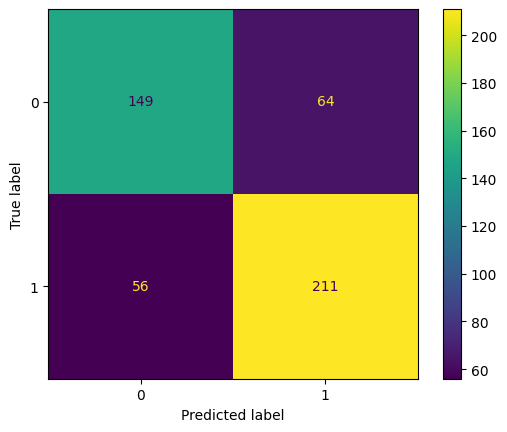

In [34]:
y_pred = classifier.predict(X_test_norm)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

In [35]:
y_train.value_counts()

,count
decisao,
1,588
0,531


In [36]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.73      0.70      0.71       213
           1       0.77      0.79      0.78       267

    accuracy                           0.75       480
   macro avg       0.75      0.74      0.75       480
weighted avg       0.75      0.75      0.75       480



In [41]:
dot_data = export_graphviz(
    classifier,
    out_file=None,
    feature_names=X.columns,
    class_names=['Baixa Qualidade', 'Alta Qualidade'],
    filled=True,
    rounded=True,
    special_characters=True
)

In [42]:
graph = graphviz.Source(dot_data)

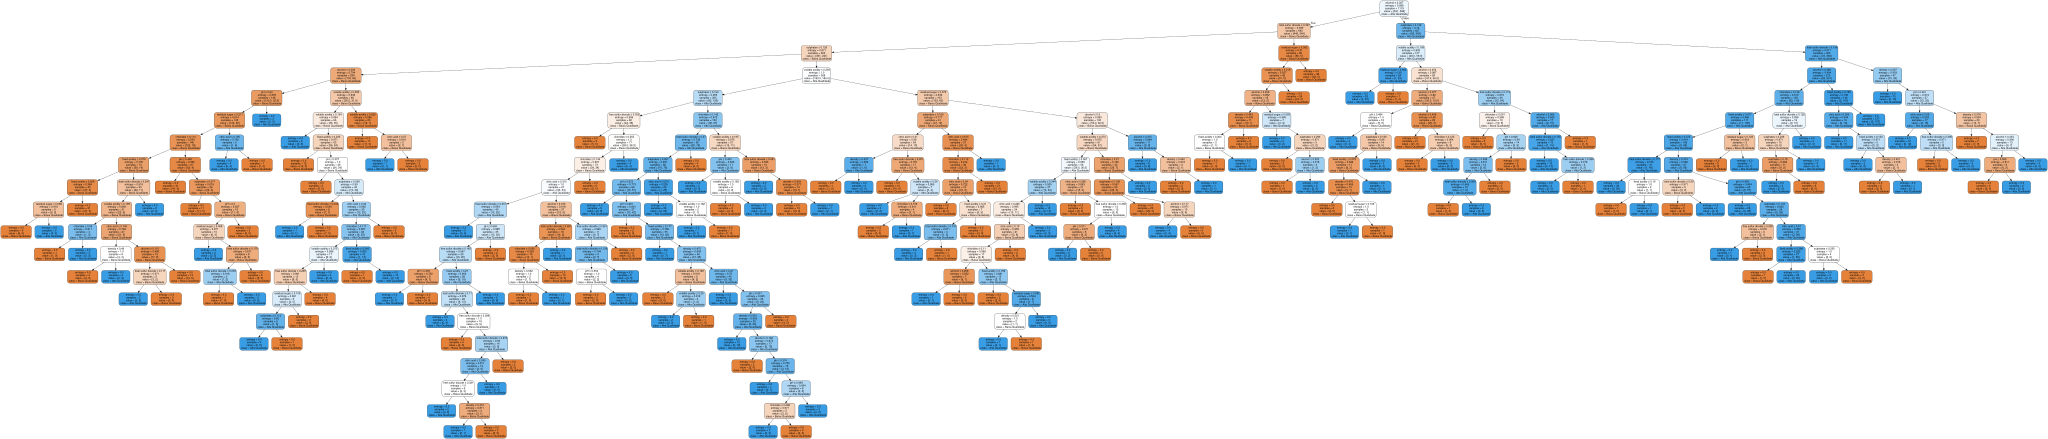

In [43]:
graph.render("decision_tree_wine", format="png", cleanup=False)
graph

In [45]:
from sklearn.model_selection import GridSearchCV

# Definir parâmetros para busca

params = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

In [47]:
# Buscar melhores parâmetros

grid_search = GridSearchCV(classifier, params, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(criterion='entropy',
                                              random_state=25),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [48]:
best_model = grid_search.best_estimator_
print(best_model)

DecisionTreeClassifier(min_samples_split=10, random_state=25)


In [49]:
classifier_2 = DecisionTreeClassifier(min_samples_split=10, random_state=25)
classifier_2.fit(X_train_norm, y_train)

DecisionTreeClassifier(min_samples_split=10, random_state=25)

              precision    recall  f1-score   support

           0       0.72      0.71      0.72       213
           1       0.77      0.78      0.77       267

    accuracy                           0.75       480
   macro avg       0.74      0.74      0.74       480
weighted avg       0.75      0.75      0.75       480



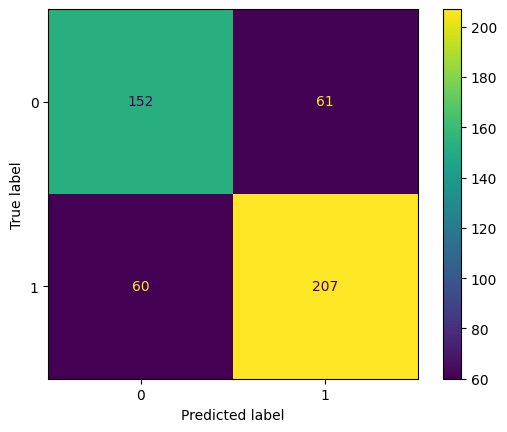

In [50]:
y_pred = classifier_2.predict(X_test_norm)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=classifier_2.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier_2.classes_)
disp.plot()
plt.show()

In [51]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.72      0.71      0.72       213
           1       0.77      0.78      0.77       267

    accuracy                           0.75       480
   macro avg       0.74      0.74      0.74       480
weighted avg       0.75      0.75      0.75       480



In [52]:
dot_data = export_graphviz(
    classifier,
    out_file=None,
    feature_names=X.columns,
    class_names=['Baixa Qualidade', 'Alta Qualidade'],
    filled=True,
    rounded=True,
    special_characters=True
)

In [53]:
graph = graphviz.Source(dot_data)

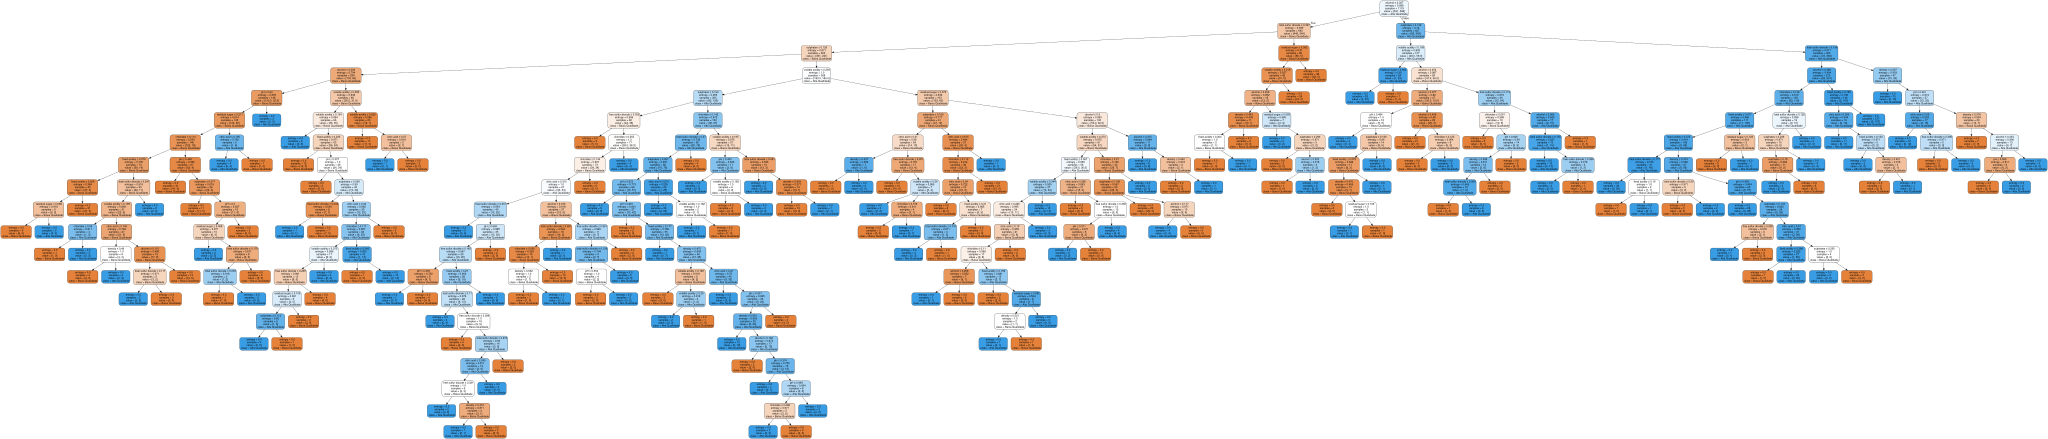

In [54]:
graph.render("decision_tree_wine", format="png", cleanup=False)
graph

In [55]:
y_train.value_counts()

,count
decisao,
1,588
0,531


In [62]:
# Utilizando o Oversampling
from imblearn.over_sampling import SMOTE

smt = SMOTE(random_state=0)
X_over, y_over = smt.fit_resample(X_train_norm, y_train)
y_over.value_counts() # Quantidade balanceada pela classe com mais exemplos

,count
decisao,
1,588
0,588


In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm(model, X, y, format='.3f'):
    """Função para exibir a matriz de confusão"""

    ConfusionMatrixDisplay.from_estimator(model, X, y,
                                          values_format=format,
                                          cmap='Blues',
                                          normalize='true')
    plt.show()

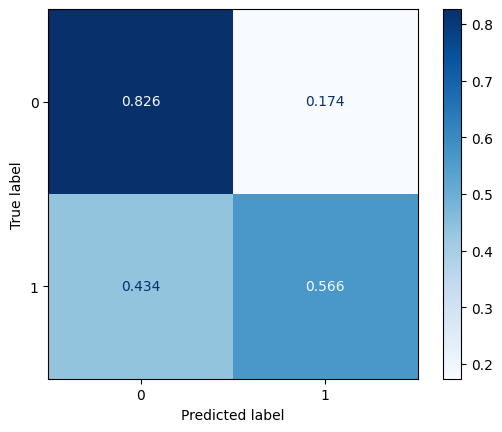

In [63]:
dt_over = DecisionTreeClassifier(random_state=0,
                             criterion='entropy',
                             max_depth=5)

dt_over.fit(X_over, y_over)

plot_cm(dt_over, X_test_norm, y_test)

In [67]:
classifier_3 = DecisionTreeClassifier(min_samples_split=10, random_state=25)
classifier_3.fit(X_train_norm, y_train)

DecisionTreeClassifier(min_samples_split=10, random_state=25)

              precision    recall  f1-score   support

           0       0.72      0.71      0.72       213
           1       0.77      0.78      0.77       267

    accuracy                           0.75       480
   macro avg       0.74      0.74      0.74       480
weighted avg       0.75      0.75      0.75       480



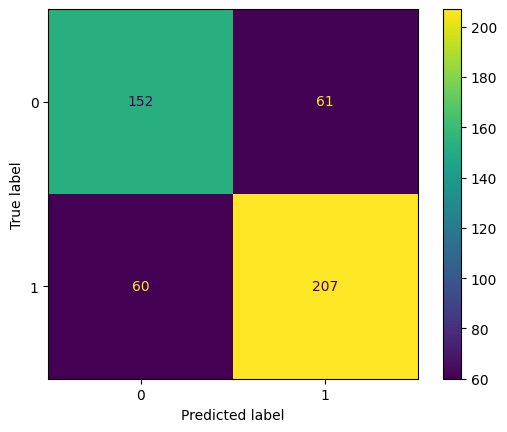

In [68]:
y_pred = classifier_3.predict(X_test_norm)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=classifier_3.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier_3.classes_)
disp.plot()
plt.show()

In [71]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weights

array([1.05367232, 0.95153061])

In [72]:
class_weights[1]/class_weights[0]

np.float64(0.903061224489796)

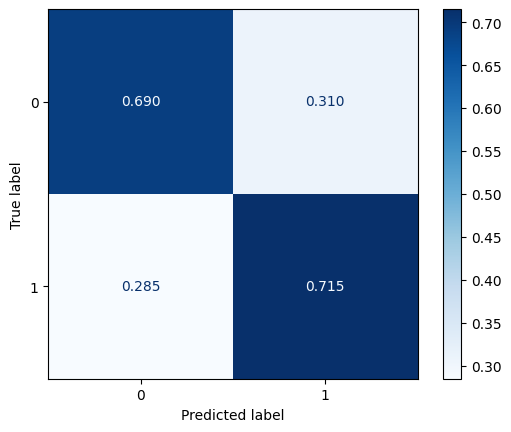

In [85]:
dt = DecisionTreeClassifier(random_state=0,
                            criterion='entropy',
                            max_depth=5,
                            class_weight={0: 1.5,1: 1.8})

dt.fit(X_train_norm, y_train)

plot_cm(dt, X_test_norm, y_test)

In [86]:
print(f'Accuracy #1: {classifier.score(X_test_norm, y_test)}')
print(f'Accuracy #4: {dt.score(X_test_norm, y_test)}')

Accuracy #1: 0.75
Accuracy #4: 0.7041666666666667
